### Introduction ###





### Mathematical Model ###




$$
\frac{dP}{dt} = k_{rel} \cdot I - k_{elim} \cdot P
$$





$$
\frac{dP}{dt} = (n \cdot t^{n-1}) \cdot I - k_{elim} \cdot P
$$



### Results ###

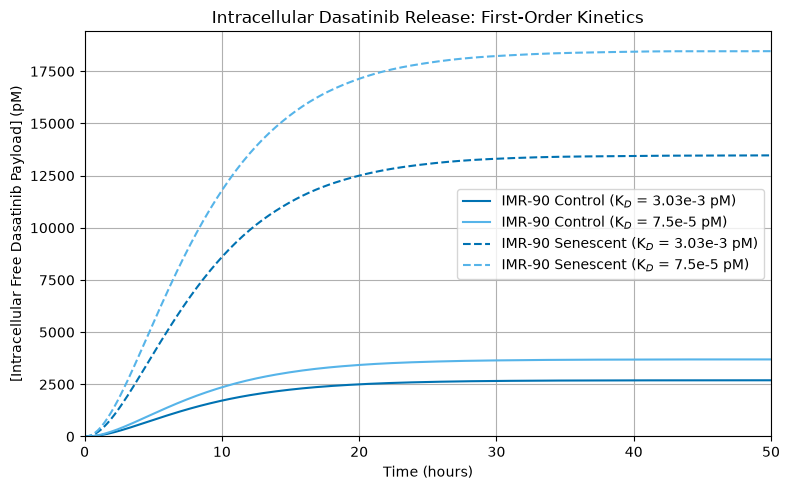

In [1]:
import sys
import numpy as np
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from src.plotting import plot_comp, dev_comp
from src.binding import run_binding_model
from src.endocytosis import run_endocytosis_model
from src.payload import run_payload_model
from src.constants import *

B_HEAL1 = run_binding_model(R_HEAL, KOFF1, 432000)
B_SEN1 = run_binding_model(R_SEN, KOFF1, 432000)
B_HEAL2 = run_binding_model(R_HEAL, KOFF2, 432000)
B_SEN2 = run_binding_model(R_SEN, KOFF2, 432000)

I_HEAL1 = run_endocytosis_model(B_HEAL1, 2)
I_SEN1 = run_endocytosis_model(B_SEN1, 2)
I_HEAL2 = run_endocytosis_model(B_HEAL2, 2)
I_SEN2 = run_endocytosis_model(B_SEN2, 2)

load_heal1 = run_payload_model(I_HEAL1)
load_sen1 = run_payload_model(I_SEN1)
load_heal2 = run_payload_model(I_HEAL2)
load_sen2 = run_payload_model(I_SEN2)

plot_comp("Intracellular Dasatinib Release: First-Order Kinetics", "Time (hours)", "[Intracellular Free Dasatinib Payload] (pM)", 50,
        (load_heal1.t/3600, load_heal1.y[0], r"IMR-90 Control (K$_D$ = 3.03e-3 pM)"),
        (load_heal2.t/3600, load_heal2.y[0], r"IMR-90 Control (K$_D$ = 7.5e-5 pM)"),
        (load_sen1.t/3600, load_sen1.y[0], r"IMR-90 Senescent (K$_D$ = 3.03e-3 pM)"),
        (load_sen2.t/3600, load_sen2.y[0], r"IMR-90 Senescent (K$_D$ = 7.5e-5 pM)"))


Figure 4.1. Intracellular liberation profile of free Dasatinib from internalized nanocarriers assuming a constant, time-independent first-order matrix release rate k<sub>rel</sub> inside the cell.

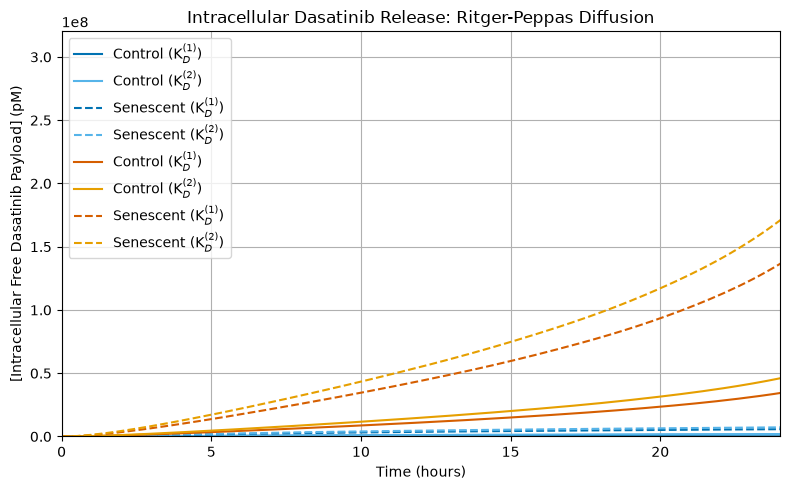

In [2]:
B_HEAL1, B_SEN1 = [run_binding_model(R, KOFF1, 432000) for R in [R_HEAL, R_SEN]]
B_HEAL2, B_SEN2 = [run_binding_model(R, KOFF2, 432000) for R in [R_HEAL, R_SEN]]

I_HEAL1, I_SEN1, I_HEAL2, I_SEN2 = [
    run_endocytosis_model(B, 2) for B in [B_HEAL1, B_SEN1, B_HEAL2, B_SEN2]]

P_HEAL1, P_SEN1, P_HEAL2, P_SEN2 = [
    run_payload_model(I, B, 2, n1, VMAX1) for I, B in zip([I_HEAL1, I_SEN1, I_HEAL2, I_SEN2], [B_HEAL1, B_SEN1, B_HEAL2, B_SEN2])]

P_HEAL3, P_SEN3, P_HEAL4, P_SEN4 = [
    run_payload_model(I, B, 2, n2, VMAX1) for I, B in zip([I_HEAL1, I_SEN1, I_HEAL2, I_SEN2], [B_HEAL1, B_SEN1, B_HEAL2, B_SEN2])]

plot_comp("Intracellular Dasatinib Release: Ritger-Peppas Diffusion", "Time (hours)", "[Intracellular Free Dasatinib Payload] (pM)", 24,
    # n = 0.43
        (P_HEAL1.t/3600, P_HEAL1.P, r"Control (K$_D^{(1)}$)"), 
        (P_HEAL2.t/3600, P_HEAL2.P, r"Control (K$_D^{(2)}$)"),
        (P_SEN1.t/3600, P_SEN1.P, r"Senescent (K$_D^{(1)}$)"),
        (P_SEN2.t/3600, P_SEN2.P, r"Senescent (K$_D^{(2)}$)"),
    # n = 0.60
        (P_HEAL3.t/3600, P_HEAL3.P, r"Control (K$_D^{(1)}$)"),
        (P_HEAL4.t/3600, P_HEAL4.P, r"Control (K$_D^{(2)}$)"),
        (P_SEN3.t/3600, P_SEN3.P, r"Senescent (K$_D^{(1)}$)"),
        (P_SEN4.t/3600, P_SEN4.P, r"Senescent (K$_D^{(2)}$)"))


Figure 4.2. 

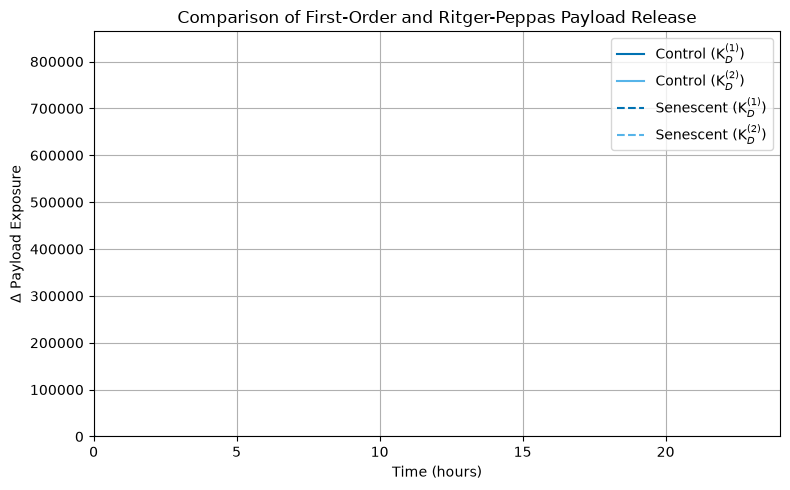

In [3]:
# 4.3 comparison plot of ritger peppas and first order kinetics
# y = diff in payload exposure / payload ratio
# Comparison of First-Order and Ritger-Peppas Payload Release

peppas = [P_HEAL1, P_HEAL2, P_SEN1, P_SEN2]
firstorder = [load_heal1, load_heal2, load_sen1, load_sen2]
labels = [r"Control (K$_D^{(1)}$)", r"Control (K$_D^{(2)}$)", r"Senescent (K$_D^{(1)}$)", r"Senescent (K$_D^{(2)})$"]

datasets = dev_comp(peppas, firstorder, "sub", labels)

plot_comp("Comparison of First-Order and Ritger-Peppas Payload Release", "Time (hours)", r"$\Delta$ Payload Exposure", 24, *datasets)


Figure 4.3. 

### Interpretation ###

### Limitations ###

"This Ritger–Peppas implementation uses global simulation time as the release clock. Newly internalised nanoparticles therefore inherit the same release “age” as older nanoparticles. Treat it as a release-profile approximation, not a fully mechanistic particle-age model. Also report where F(t)=ktn≤0.6F(t)=kt^n\leq0.6F(t)=ktn≤0.6, because results beyond that region extrapolate the Ritger–Peppas relationship."

The Quasi-Steady-State (QSS) Approximation vs current The Michaelis-Menten (MM) Approximation (endocytosis... not payload)

### Discussion ###



